<a href="https://colab.research.google.com/github/eeshahar/data-science/blob/main/EeshHariU8proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Project: Writing a BARTical

In [ ]:
!pip install preliz
!pip install bambi

In [ ]:
!pip install -q "preliz[full,notebook]"
!pip install -q bambi

In [7]:

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb
import graphviz as gv
import seaborn as sns


In [ ]:
!pip install pymc-bart

In [9]:
import pymc_bart as pmb

**Data:** https://www.kaggle.com/competitions/soaicommunitydatathon23-stress-detection

**Context:** For this project, I decided to use a dataset that involves n

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
house = pd.read_csv("/content/drive/MyDrive/Data science/AmesHousing.csv")
print(house.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [12]:
features = [
    'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Garage Area',
    'Full Bath', 'Half Bath', 'TotRms AbvGrd', 'Year Built',
    'Year Remod/Add', 'Overall Qual', 'Overall Cond', 'SalePrice'
]
df = house[features].dropna()

In [13]:
print(df.columns)

Index(['Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Garage Area', 'Full Bath',
       'Half Bath', 'TotRms AbvGrd', 'Year Built', 'Year Remod/Add',
       'Overall Qual', 'Overall Cond', 'SalePrice'],
      dtype='object')


In [14]:
df

,Gr Liv Area,Total Bsmt SF,Lot Area,Garage Area,Full Bath,Half Bath,TotRms AbvGrd,Year Built,Year Remod/Add,Overall Qual,Overall Cond,SalePrice
0,1656,1080.0,31770,528.0,1,0,7,1960,1960,6,5,215000
1,896,882.0,11622,730.0,1,0,5,1961,1961,5,6,105000
2,1329,1329.0,14267,312.0,1,1,6,1958,1958,6,6,172000
3,2110,2110.0,11160,522.0,2,1,8,1968,1968,7,5,244000
4,1629,928.0,13830,482.0,2,1,6,1997,1998,5,5,189900
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,1003,1003.0,7937,588.0,1,0,6,1984,1984,6,6,142500
2926,902,864.0,8885,484.0,1,0,5,1983,1983,5,5,131000
2927,970,912.0,10441,0.0,1,0,6,1992,1992,5,5,132000
2928,1389,1389.0,10010,418.0,1,0,6,1974,1975,5,5,170000


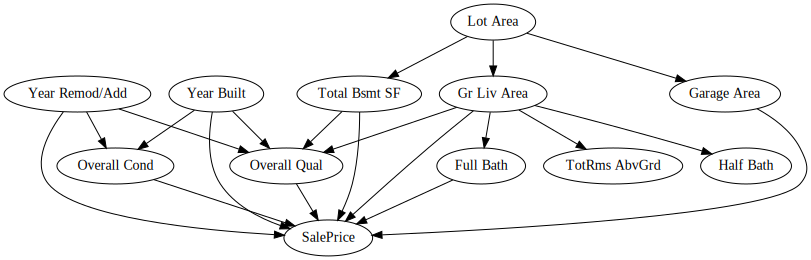

In [15]:
import graphviz as gv

b_dag = gv.Digraph(name="Ames Housing Causal DAG")

# Nodes
b_dag.node('LA', 'Lot Area')
b_dag.node('YB', 'Year Built')
b_dag.node('YR', 'Year Remod/Add')
b_dag.node('GLA', 'Gr Liv Area')
b_dag.node('TBSF', 'Total Bsmt SF')
b_dag.node('GA', 'Garage Area')
b_dag.node('FB', 'Full Bath')
b_dag.node('HB', 'Half Bath')
b_dag.node('TR', 'TotRms AbvGrd')
b_dag.node('OQU', 'Overall Qual')
b_dag.node('OCN', 'Overall Cond')
b_dag.node('SP', 'SalePrice')

# Edges
b_dag.edges([
    ('LA', 'GLA'), ('LA', 'TBSF'), ('LA', 'GA'),
    ('YB', 'OQU'), ('YB', 'OCN'), ('YB', 'SP'),
    ('YR', 'OQU'), ('YR', 'OCN'), ('YR', 'SP'),
    ('GLA', 'TR'), ('GLA', 'FB'), ('GLA', 'HB'), ('GLA', 'OQU'), ('GLA', 'SP'),
    ('TBSF', 'OQU'), ('TBSF', 'SP'),
    ('GA', 'SP'),
    ('OQU', 'SP'),
    ('OCN', 'SP'),
    ('FB', 'SP')
])

b_dag

At first glance of all the columns in the dataset, I realize that some of them, especially variables that were binary, probably wouldn't be the best help in trying to predict anything. Of the variables listed above, I'm to dropping gender, dizziness, and medication, because those don't seem to have as clear of a correlation to any of the variables I'm interested in predicting.

Predicting anxiety Level is the way to go because so many arrows lead to it. Stress level would also be a good idea but I think that predicting anxiety is more interesting because with stress, it can sometimes be obvious what the leading causes are whereas with anxiety it can be hidden under the surface.

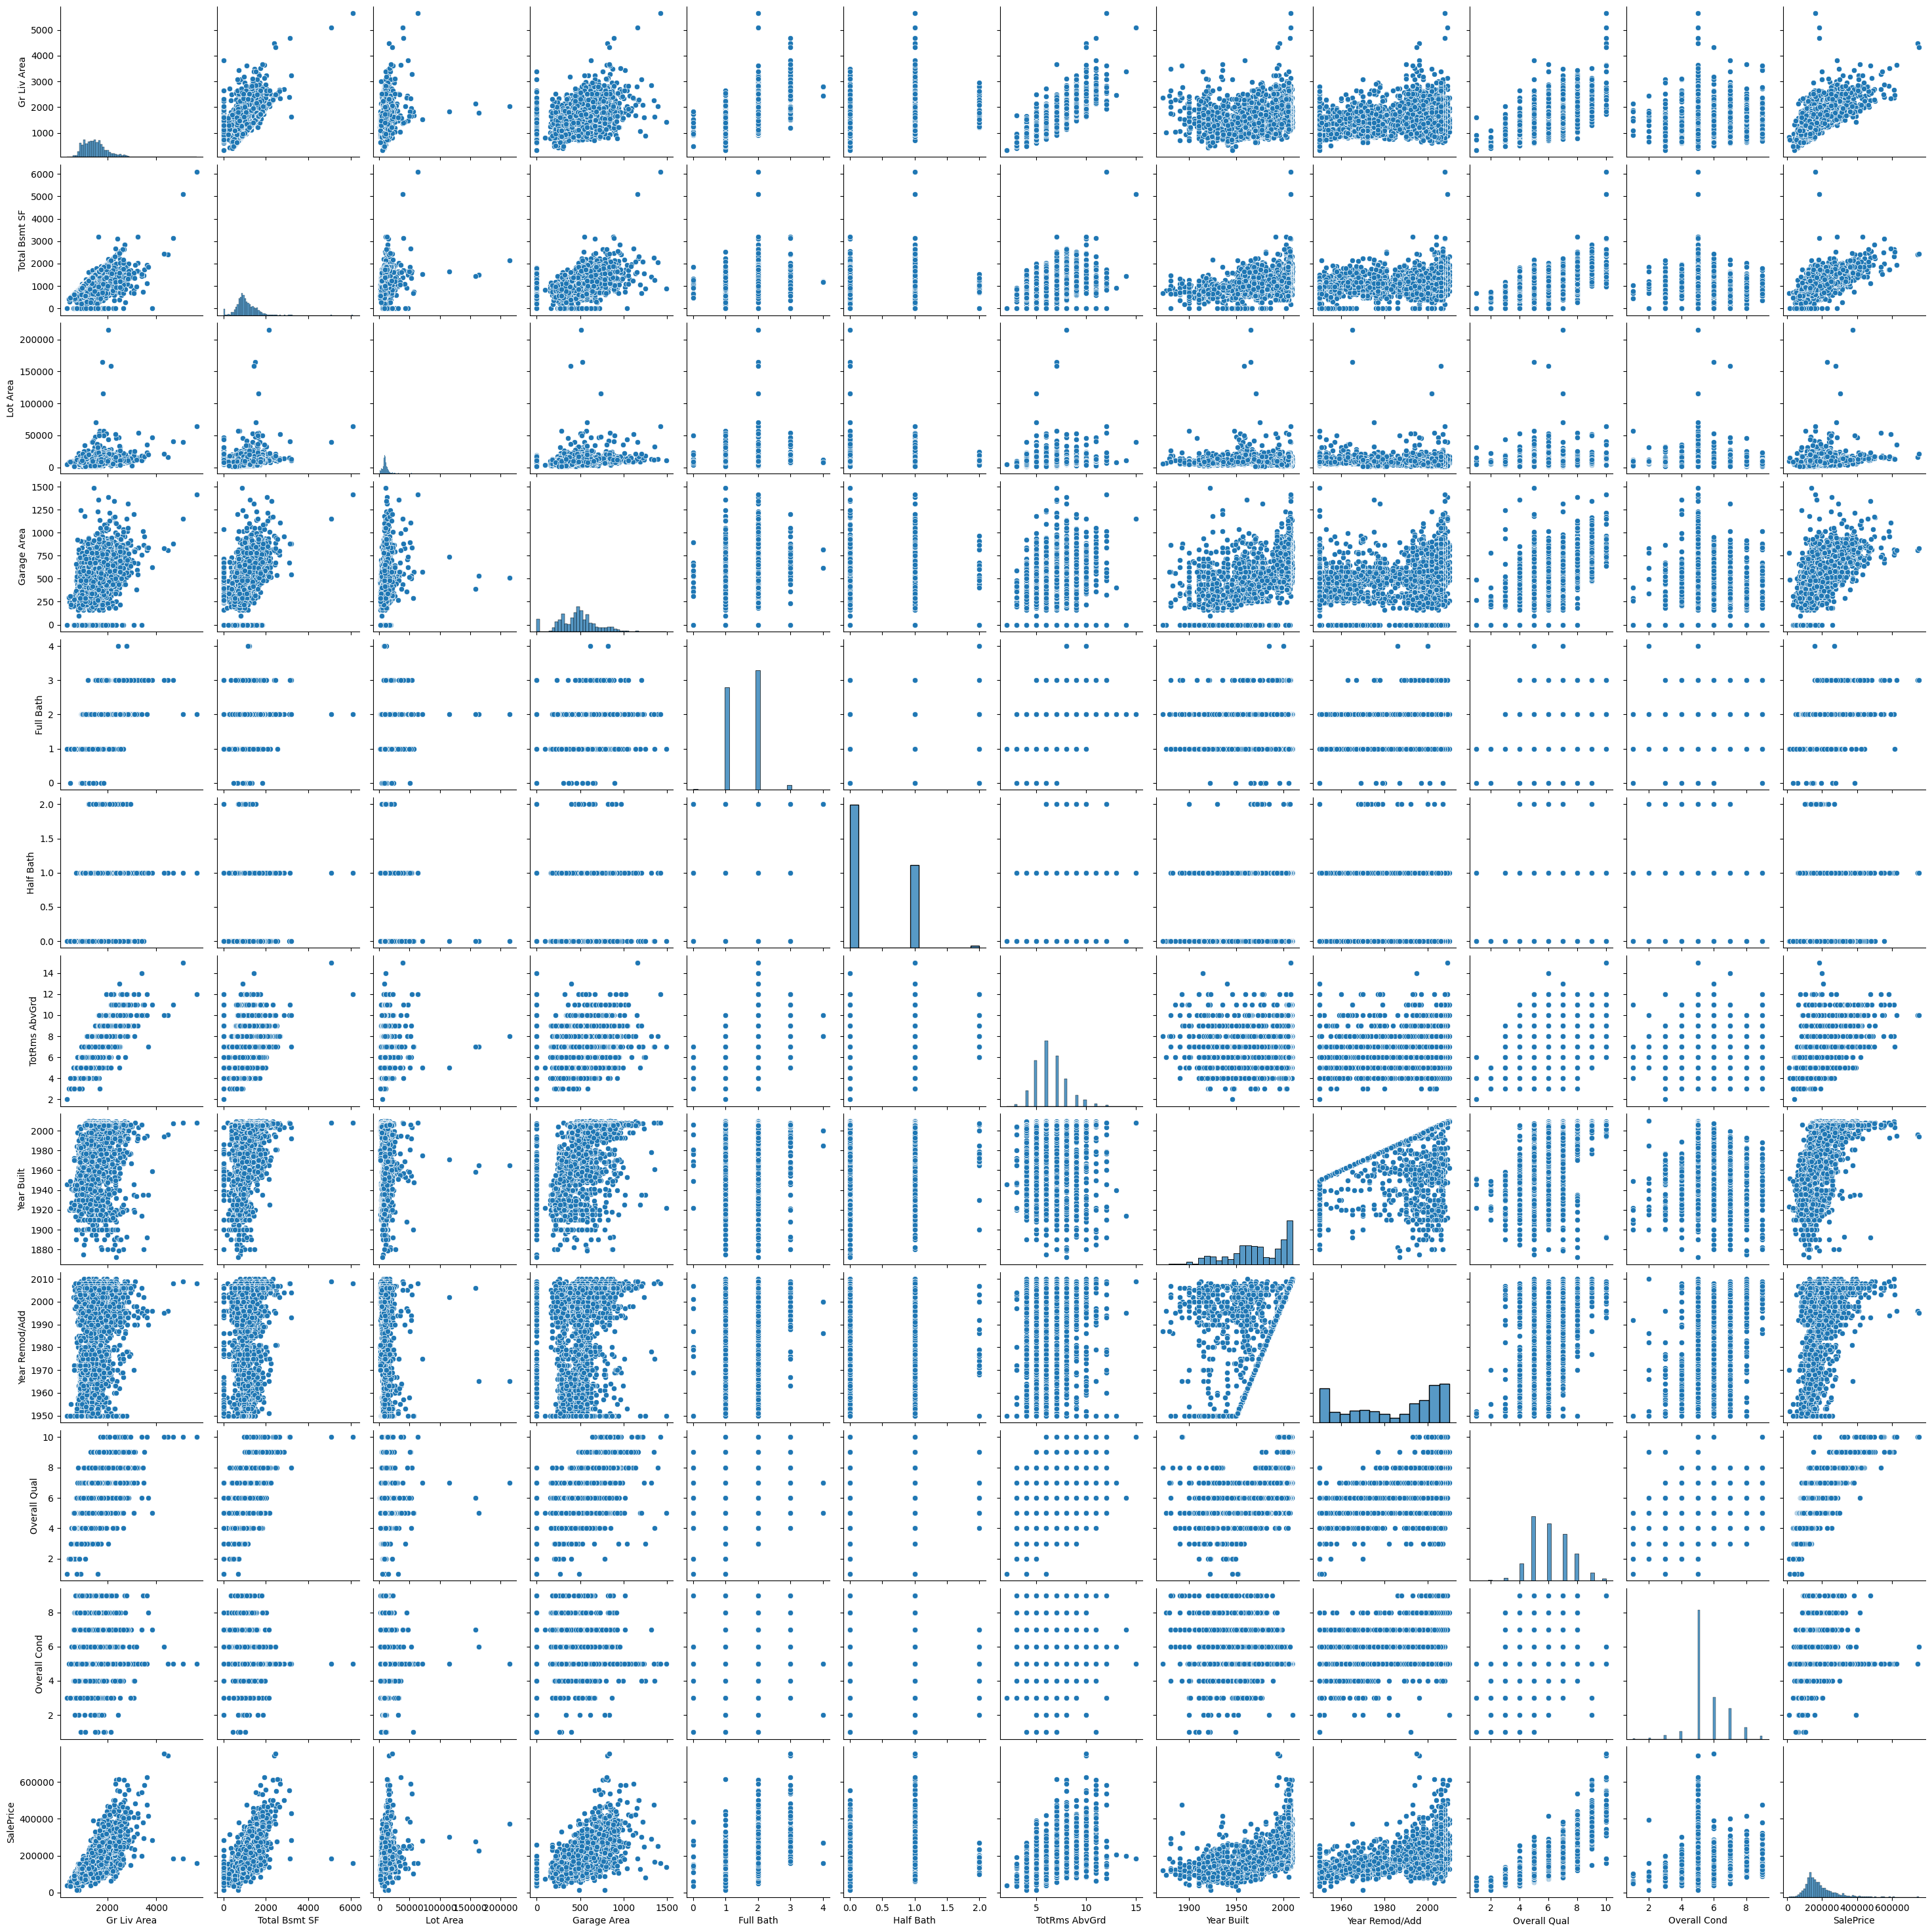

In [16]:
sns.pairplot(df)

Mounted at /content/drive


Output()

/usr/local/lib/python3.12/dist-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


array([[<Axes: title={'center': 'Gr Liv Area'}>,
        <Axes: title={'center': 'Gr Liv Area'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'Overall Qual'}>,
        <Axes: title={'center': 'Overall Qual'}>],
       [<Axes: title={'center': 'Total Bsmt SF'}>,
        <Axes: title={'center': 'Total Bsmt SF'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

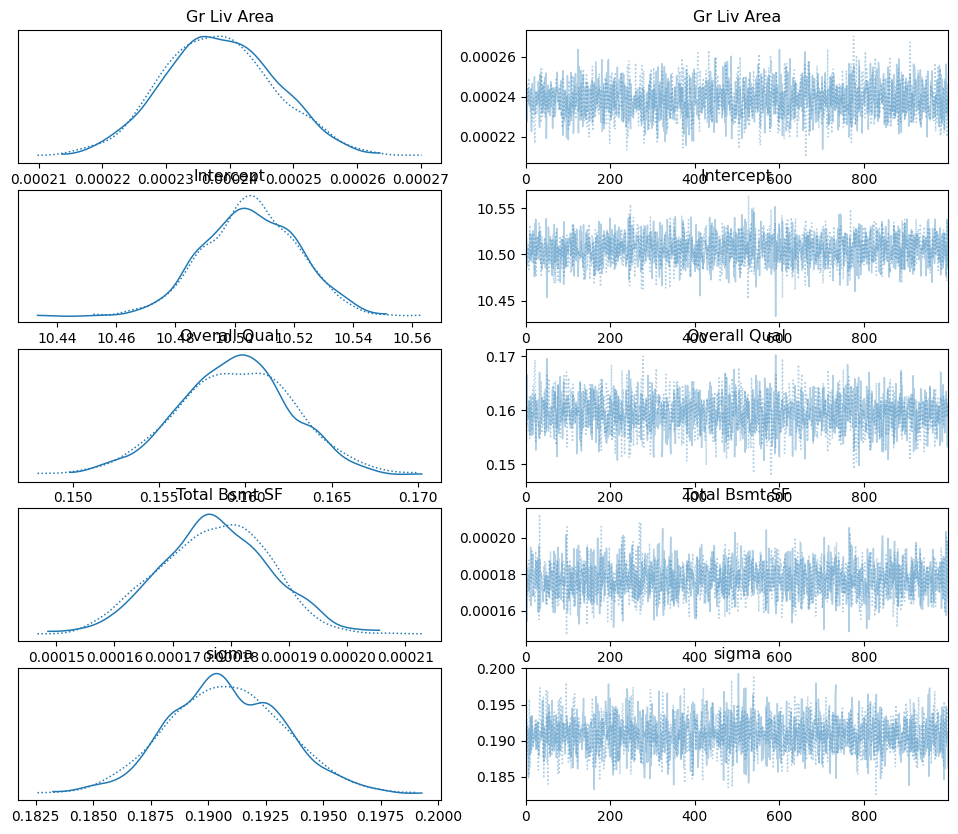

In [23]:
import numpy as np
import pandas as pd
from google.colab import drive
import bambi as bmb
import arviz as az

# Ensure drive is mounted and data is loaded if not already done
# This code is duplicated from earlier cells to make this cell runnable independently
drive.mount('/content/drive', force_remount=True)
house = pd.read_csv("/content/drive/MyDrive/Data science/AmesHousing.csv")
features = [
    'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Garage Area',
    'Full Bath', 'Half Bath', 'TotRms AbvGrd', 'Year Built',
    'Year Remod/Add', 'Overall Qual', 'Overall Cond', 'SalePrice'
]
df = house[features].dropna()

# Model 1: Log-Normal Regression (using log-transformed response)
df['Log_SalePrice'] = np.log(df['SalePrice'])
model_log = bmb.Model("Log_SalePrice ~ `Gr Liv Area` + `Total Bsmt SF` + `Overall Qual`",
                      df, family="gaussian")
idata_log = model_log.fit(draws=1000, tune=1000, record_likelihood=True)

# Check the fit in the project style
az.plot_trace(idata_log, var_names=["~mu"])

In [28]:
model_poly_ames = bmb.Model("SalePrice ~ `Gr Liv Area` + I(`Gr Liv Area`**2) + `Overall Qual`", df, family="gaussian")
idata_poly_ames = model_poly_ames.fit(record_likelihood=True)

Output()

In [29]:
#from gemini
X_simple = df["Gr Liv Area"].to_numpy().reshape(-1, 1)
Y = df["SalePrice"].to_numpy()

with pm.Model() as model_bart_3:
    s = pm.HalfNormal('s', Y.std())
    μ = pmb.BART("μ", X_simple, Y, m=10)
    y = pm.Normal("y", mu=μ, sigma=s, observed=Y)
    idata_bart_3 = pm.sample(compute_convergence_checks=False)

Output()

In [30]:
features_multi = ['Gr Liv Area', 'Total Bsmt SF', 'Overall Qual', 'Year Built']
X_multi = df[features_multi].to_numpy()
Y_multi = df["SalePrice"].to_numpy()

with pm.Model() as model_bart_4:
    s = pm.HalfNormal('s', Y_multi.std())
    μ_multi = pmb.BART("μ_multi", X_multi, Y_multi, m=10)
    y_multi = pm.Normal("y_multi", mu=μ_multi, sigma=s, observed=Y_multi)
    idata_bart_4 = pm.sample(compute_convergence_checks=False)

Output()

In [31]:
# Compute log_likelihood for BART Simple model
with model_bart_3:
    pm.compute_log_likelihood(idata_bart_3)

# Compute log_likelihood for BART Multi model
with model_bart_4:
    pm.compute_log_likelihood(idata_bart_4)

print("Log-likelihood computed for BART models.")

Output()

Output()

Log-likelihood computed for BART models.


In [ ]:
print(f"idata_log has log_likelihood: {hasattr(idata_log, 'log_likelihood')}")
print(f"idata_poly_ames has log_likelihood: {hasattr(idata_poly_ames, 'log_likelihood')}")

Output()

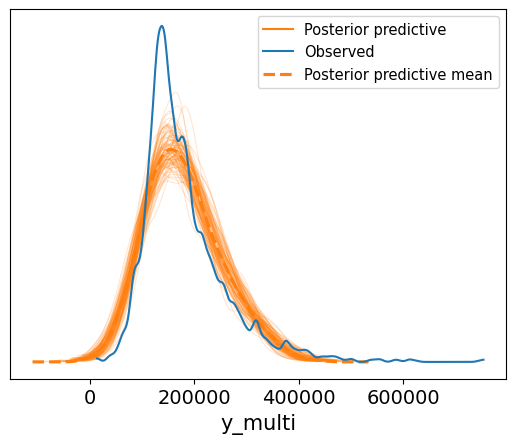

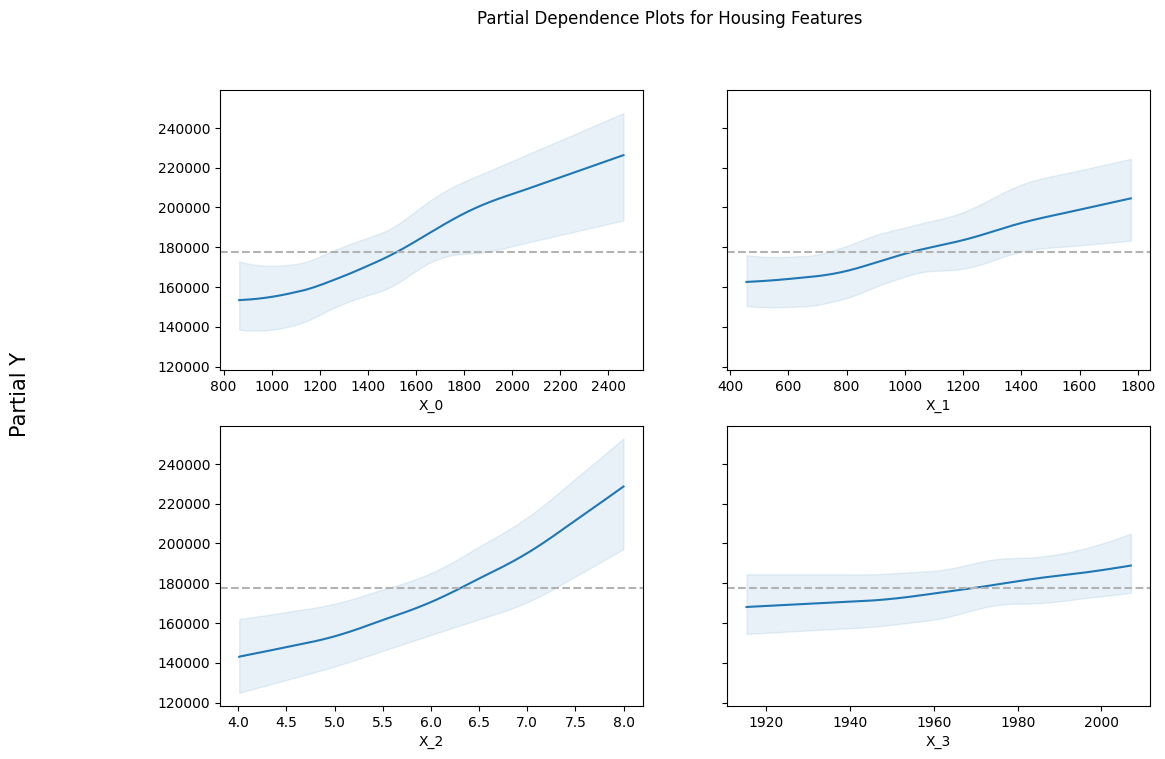

In [21]:
pm.sample_posterior_predictive(idata_bart_4, model=model_bart_4, extend_inferencedata=True)
az.plot_ppc(idata_bart_4, num_pp_samples=100, colors=["C1", "C0", "C1"])

#from gemini
# Note: X_multi and Y_multi must be defined as in the previous step
pmb.plot_pdp(μ_multi, X_multi, Y_multi, grid=(2, 2), figsize=(12, 8))
plt.suptitle("Partial Dependence Plots for Housing Features")
plt.show()

In [22]:
# Create the comparison dictionary
model_dict = {
    "Bambi Log-Normal": idata_log,
    "Bambi Poly": idata_poly_ames,
    "BART Simple": idata_bart_3,
    "BART Multi": idata_bart_4
}

# Run the comparison
comp = az.compare(model_dict)

# Display the comparison table
print(comp)

# Plot the comparison (visual "thing")
az.plot_compare(comp)
plt.title("Model Comparison (LOO Score)")
plt.show()

TypeError: Encountered error in ELPD computation of compare.